<a href="https://colab.research.google.com/github/MartaPetrovska/Python/blob/main/Titanic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

titanic_df = pd.read_csv('/content/train.csv')
titanic_df.head(5) #check what data is in DataFrame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic_df.shape

(891, 12)

In [6]:
titanic_df.isna().sum() # check which columns contains NaN

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
titanic_df.info() #check which columns are numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
numeric_columns = titanic_df.select_dtypes(include=['number']) # mean values for numeric columns
mean_values = numeric_columns.mean()
print(mean_values)

PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64


In [10]:
max_values = numeric_columns.max() # max values for numeric columns
print(max_values)

PassengerId    891.0000
Survived         1.0000
Pclass           3.0000
Age             80.0000
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64


In [11]:
min_values = numeric_columns.min()# min values for numeric columns
print(min_values)

PassengerId    1.00
Survived       0.00
Pclass         1.00
Age            0.42
SibSp          0.00
Parch          0.00
Fare           0.00
dtype: float64


In [12]:
median_values = numeric_columns.median() #meadian values for numeric columns
print(median_values)

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64


In [14]:
sex_counts = titanic_df['Sex'].value_counts()
print(sex_counts)

Sex
male      577
female    314
Name: count, dtype: int64


In [44]:
parch_counts = titanic_df['Parch'].value_counts() # people with parents or childrens on the board
print(parch_counts)

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [45]:
sibling_counts = titanic_df['SibSp'].value_counts()# people with siblings on the board
print(sibling_counts)

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


Text(0, 0.5, 'Count')

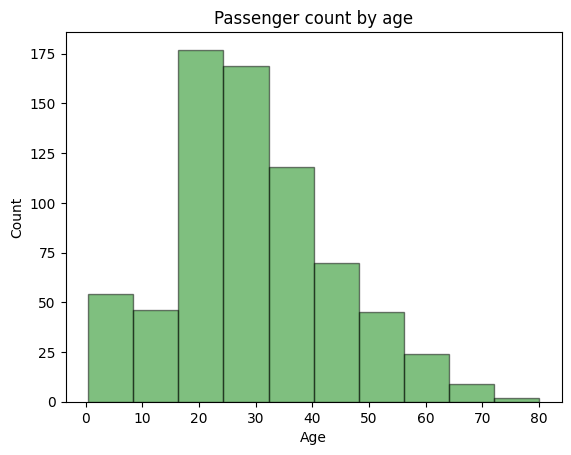

In [46]:
plt.hist(titanic_df['Age'], color='green', edgecolor='black', alpha=0.5)
plt.title('Passenger count by age')
plt.xlabel('Age')
plt.ylabel('Count')

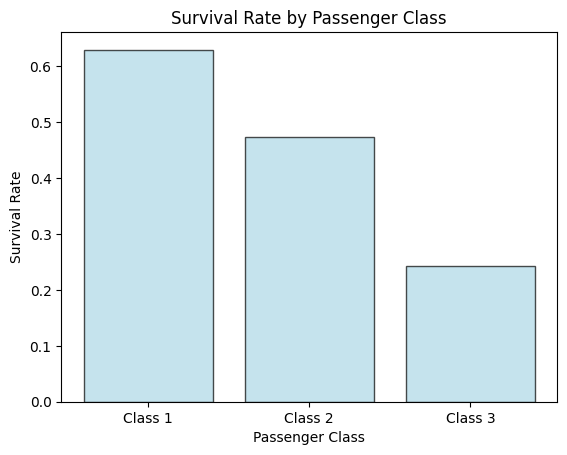

In [42]:
survival_rate = titanic_df.groupby('Pclass')['Survived'].mean().reset_index()
plt.bar(survival_rate['Pclass'], survival_rate['Survived'], color='lightblue', edgecolor='black', alpha=0.7)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(ticks=survival_rate['Pclass'], labels=['Class 1', 'Class 2', 'Class 3'])
plt.show()